In [1]:
import zipfile
import os

# Path to the zip file
zip_path = r'Shark_v2_moxland_L23_HBT_PSO_default.zip'
extract_to = 'moxland_extracted'  # New folder to hold extracted files

# Extract the zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

print(f"Extraction complete. Files extracted to: {extract_to}")

# Define list of subvolumes
sv_list = range(64)

# Loop through each simulation run
runs = ['161', '177', '201']
for run in runs:
    base_dir = f'moxland_extracted/Shark_v2_moxland_L23_HBT_PSO_default/{run}'
    sharkfiles = [f'{base_dir}/{sv}/galaxies.hdf5' for sv in sv_list]

    # Example: Check if files exist
    all_exist = all(os.path.exists(f) for f in sharkfiles)
    print(f"Run {run}: All files exist? {all_exist}")

    # Placeholder for actual processing:
    # shark_csv = processor.process_all_subvolumes(sv_list, sharkfiles)
    # do something with shark_csv...


Extraction complete. Files extracted to: moxland_extracted
Run 161: All files exist? True
Run 177: All files exist? True
Run 201: All files exist? True


In [3]:
########################################
# Packages
########################################
import warnings
import h5py as h5
import numpy as np
import pandas as pd
import multiprocessing as mp

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

import math

import statistics

from scipy import stats
from scipy.stats import gaussian_kde
from scipy.stats import binned_statistic
import scipy.stats.distributions as dist

import seaborn as sns

In [4]:
# CHANDRO-GOMEZ 25 (z=0)
from data_processing import SHARKDataProcessor
processor = SHARKDataProcessor()

# Define subvolume IDs and HDF5 file paths for snapshot 161
sv_list = np.arange(64)
sharkfiles = [f'moxland_extracted/Shark_v2_moxland_L23_HBT_PSO_default/161/{sv}/galaxies.hdf5' for sv in sv_list]

# Process and output the shark_csv dataframe
shark_csv = processor.process_all_subvolumes(sv_list, sharkfiles)
print(shark_csv.head())

  ID_galaxy ID_subhalo    ID_subhalo_tree ID_halo  sv  type    Mhalo_host  \
0       0_0        0_1  0_161000000000002     0_1   0     0  3.804515e+13   
1    0_7595        0_1  0_161000000000002     0_1   0     2  3.804515e+13   
2     0_761        0_2  0_161000000058343     0_1   0     1  3.804515e+13   
3    0_1337        0_3  0_161000000100261     0_1   0     1  3.804515e+13   
4   0_24863        0_4  0_161000001815267     0_1   0     1  3.804515e+13   

          Mhalo   Mstar_bulge    Mstar_disc  ...  SFR_bulge   SFR_disc  \
0  3.632095e+13  1.403548e+11  1.616429e+11  ...   0.548854   1.027707   
1  1.016548e+10  1.308828e+07  4.926251e+08  ...   0.000000   0.001725   
2  2.485625e+11  1.996549e+10  2.358676e+10  ...   0.001695  20.459056   
3  1.744528e+11  1.047300e+10  2.856429e+09  ...   0.000246   1.027863   
4  1.524823e+11  6.812143e+06  8.669310e+08  ...   0.000000   0.048453   

     SFR_all           MBH  MBHacc_cold    MBHacc_hot    MBHacc_all  \
0   1.576560  1.38822

Chandro-Gomez 25'. z=0.5. Min=  9.97816437437632 Max=  14.70542160494771


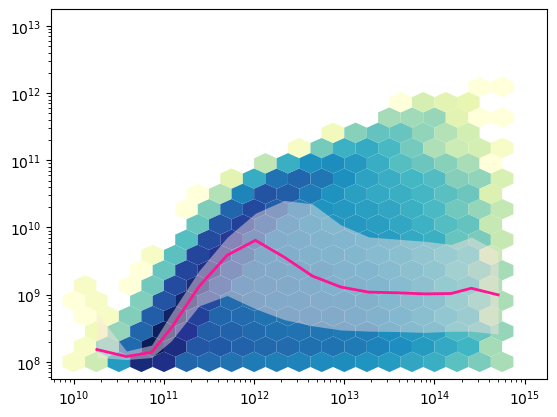

In [13]:
num_bins = 16

hb_CGz05 = plt.hexbin(shark_csv['Mhalo_host'], shark_csv['Mstar_all'], gridsize=20, xscale='log', yscale='log',
                reduce_C_function=np.sum, mincnt=1, bins='log', linewidth=0, cmap='YlGnBu',
                        extent=(np.log10(1e10), np.log10(1e15), np.log10(1e8), np.log10(1e13)))

print("Chandro-Gomez 25'. z=0.5. Min= ", np.min(np.log10(shark_csv['Mhalo_host'])), 'Max= ', np.max(np.log10(shark_csv['Mhalo_host'])))

# BINNED MEDIANS
# Calculate min and max log values of Mhalo_host
lowLog_z05 = math.log10(shark_csv['Mhalo_host'].min())
highLog_z05 = math.log10(shark_csv['Mhalo_host'].max())

# Round to the nearest whole number for log binning
lowLog_z05 = round(lowLog_z05, 0)
highLog_z05 = round(highLog_z05, 0)

# Create log bins
logBins_z05 = np.logspace(lowLog_z05, highLog_z05, num=num_bins + 1)

# MEDIAN for y-values
result_z05 = binned_statistic(shark_csv['Mhalo_host'], shark_csv['Mstar_all'], statistic='median', bins=logBins_z05)
bin_medians_z05 = result_z05.statistic

# Calculate xVals by finding the median Mhalo_host value within each bin
xVals_z05 = []
for j in range(len(logBins_z05) - 1):
    # Filter data points within the current bin
    bin_data_z05 = shark_csv['Mhalo_host'][(shark_csv['Mhalo_host'] >= logBins_z05[j]) & (shark_csv['Mhalo_host'] < logBins_z05[j+1])]
    if len(bin_data_z05) > 0:
        # Append the median of Mhalo_host values in the bin to xVals
        xVals_z05.append(np.median(bin_data_z05))
    else:
        # If no data points in the bin, append NaN or skip
        xVals_z05.append(np.nan)

# Convert xVals to a numpy array and remove NaN values (if necessary)
xVals_z05 = np.array(xVals_z05)
valid_bins_z05 = ~np.isnan(xVals_z05)
xVals_z05 = xVals_z05[valid_bins_z05]
bin_medians_z05 = bin_medians_z05[valid_bins_z05]

# PERCENTILES
# 25th percentile
percentile_25_z05 = binned_statistic(shark_csv['Mhalo_host'], shark_csv['Mstar_all'], 
                                 statistic=lambda values: np.percentile(values, 25), bins=logBins_z05)
p25_z05 = percentile_25_z05.statistic[valid_bins_z05]
# 75th percentile
percentile_75_z05 = binned_statistic(shark_csv['Mhalo_host'], shark_csv['Mstar_all'],
                                 statistic=lambda values: np.percentile(values, 75), bins=logBins_z05)
p75_z05 = percentile_75_z05.statistic[valid_bins_z05]

plt.plot(xVals_z05, bin_medians_z05, linewidth=2, color='deeppink')
plt.fill_between(xVals_z05, p25_z05, p75_z05, color='mistyrose', alpha=0.45, linewidth=0)
